In [1]:
from gensim.models import Word2Vec
from gensim.models import FastText
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
med_sentences = []

with open("TP_ISD2020/QUAERO_FrenchMed/QUAERO_FrenchMed_traindev.ospl", encoding="utf-8") as f:
    for line in f:
        med_sentences.append(line.strip().split()) 


In [3]:
vocab = set()
for sentence in med_sentences:
    for word in sentence:
        vocab.add(word)



In [4]:
set_of_words=["patient","disease", "solution", "yellow", "treatment"]

for word in set_of_words:
    print(f"Word: {word}")
    print(f'Is in the vocabulary: {word in vocab}')

Word: patient
Is in the vocabulary: True
Word: disease
Is in the vocabulary: False
Word: solution
Is in the vocabulary: True
Word: yellow
Is in the vocabulary: False
Word: treatment
Is in the vocabulary: False


In [5]:
# Model CBOW Word2Vec
model_cbow = Word2Vec(
    sentences=med_sentences,
    vector_size=100,
    min_count=1,
    sg=0
)
model_cbow.save("models_med/word2vec_cbow_med.model")

# Model Skip-gram Word2Vec
model_skipgram = Word2Vec(
    sentences=med_sentences,
    vector_size=100,
    min_count=1,
    sg=1
)
model_skipgram.save("models_med/word2vec_skipgram_med.model")

# Model CBOW FastText
model_fasttext = FastText(
    sentences=med_sentences,
    vector_size=100,
    min_count=1,
    sg=0
)
model_fasttext.save("models_med/fasttext_cbow_med.model")

In [6]:
dict_models = {
    "model_cbow": model_cbow,
    "model_skipgram": model_skipgram,
    "model_fasttext": model_fasttext
}

dictionary_similarity = {
    word: {} for word in set_of_words
}

for model_name, model in dict_models.items():

    for word in set_of_words:


        if word in model.wv.key_to_index:
            print(f"Values for {word} - model {model_name}:")
            similarity = model.wv.most_similar(word, topn=10)
            df_similarity = pd.DataFrame(similarity, columns=["word", "similarity"])
            dictionary_similarity[word][model_name] = df_similarity
            display(df_similarity)
            
        else:
            dictionary_similarity[word][model_name] = None
            print(f"Word: {word} not in vocabulary information not available for model {model_name}.")


Values for patient - model model_cbow:


,word,similarity
0,Les,0.999389
1,sur,0.999366
2,La,0.999341
3,des,0.999340
4,la,0.999327
5,le,0.999307
6,chez,0.999299
7,en,0.999295
8,sont,0.999294
9,les,0.999293


Word: disease not in vocabulary information not available for model model_cbow.
Values for solution - model model_cbow:


,word,similarity
0,pour,0.999099
1,perfusion,0.999091
2,flacon,0.999080
3,ou,0.998940
4,(,0.998924
5,),0.998867
6,",",0.998827
7,contient,0.998819
8,sous,0.998816
9,1,0.998803


Word: yellow not in vocabulary information not available for model model_cbow.
Word: treatment not in vocabulary information not available for model model_cbow.
Values for patient - model model_skipgram:


...

Word: yellow not in vocabulary information not available for model model_skipgram.
Word: treatment not in vocabulary information not available for model model_skipgram.
Values for patient - model model_fasttext:


,word,similarity
0,patiente,0.999999
1,Patient,0.999998
2,conscients,0.999994
3,présentaient,0.999994
4,prélèvements,0.999994
5,pansements,0.999994
6,Mouvements,0.999993
7,clients,0.999993
8,mouvements,0.999993
9,patients,0.999993


Word: disease not in vocabulary information not available for model model_fasttext.
Values for solution - model model_fasttext:


,word,similarity
0,Dissolution,0.999999
1,Solution,0.999998
2,evolution,0.999997
3,évolution,0.999997
4,Evolution,0.999997
5,dilution,0.999996
6,Pollution,0.999995
7,Perfusion,0.999993
8,exécution,0.999993
9,Substitution,0.999992


Word: yellow not in vocabulary information not available for model model_fasttext.
Word: treatment not in vocabulary information not available for model model_fasttext.


# Visualization

In [12]:
def heatmap(df, word_value, model_name):
    plt.figure(figsize=(3, 6))

    plt.imshow(df[["similarity"]], aspect="auto")

    plt.yticks(
        range(len(df)),
        df["word"]
    )

    plt.xticks([0], ["Similarity"])

    # Add similarity values
    for i, value in enumerate(df["similarity"]):
        plt.text(
            0, i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

    plt.title(f"Word Similarity for {word_value} - Model: {model_name}")

    plt.show()

Word: patient
Model: model_cbow


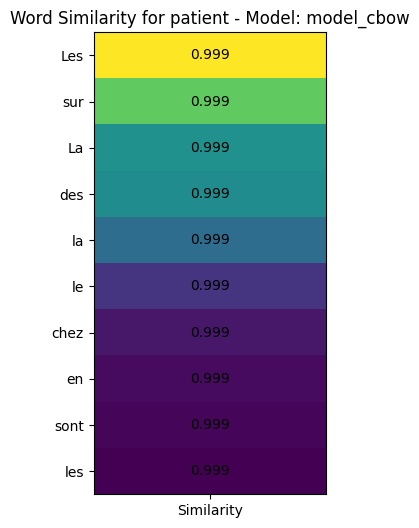

Model: model_skipgram


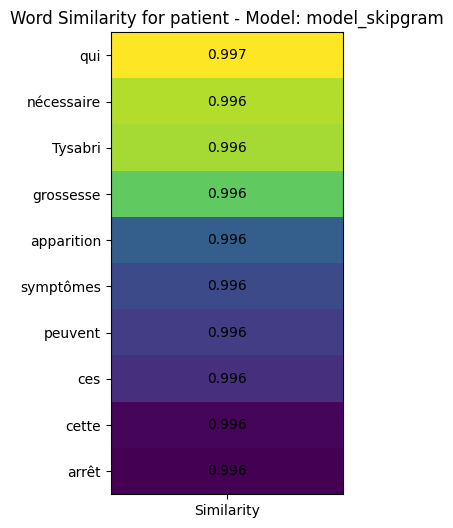

Model: model_fasttext


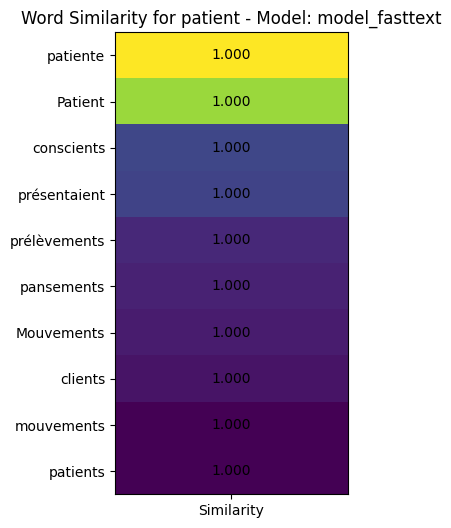

Word: disease
Model: model_cbow
No information available.
Model: model_skipgram
No information available.
Model: model_fasttext
No information available.
Word: solution
Model: model_cbow


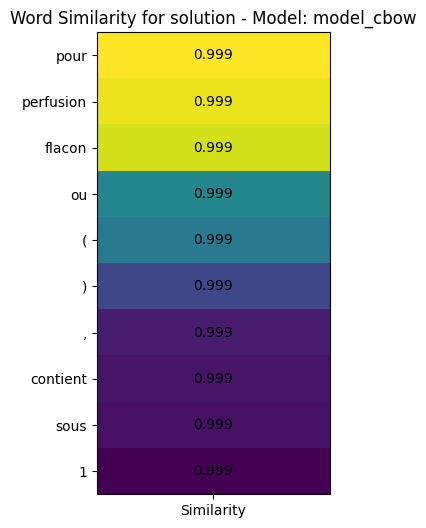

Model: model_skipgram


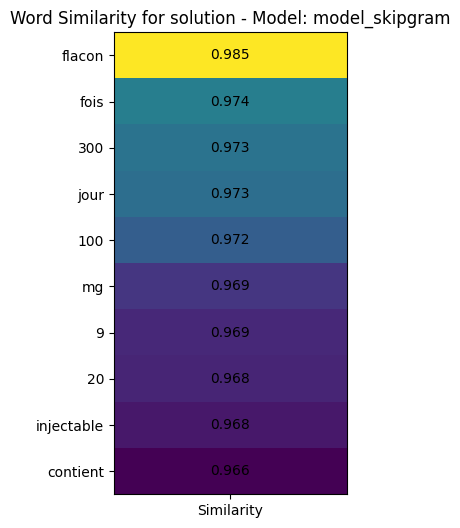

Model: model_fasttext


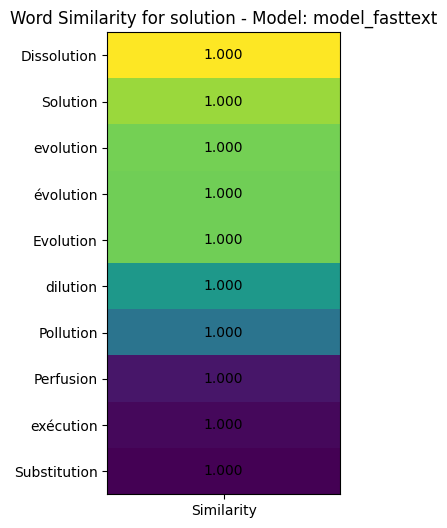

Word: yellow
Model: model_cbow
No information available.
Model: model_skipgram
No information available.
Model: model_fasttext
No information available.
Word: treatment
Model: model_cbow
No information available.
Model: model_skipgram
No information available.
Model: model_fasttext
No information available.


In [13]:
for word in dictionary_similarity:
    print(f"Word: {word}")
    for model in dictionary_similarity[word]:
        print(f"Model: {model}")
        if dictionary_similarity[word][model] is not None:
            heatmap(dictionary_similarity[word][model], word, model)
        else:
            print("No information available.")